In [2]:
import cv2 as cv
import numpy as np
import math
from google.colab.patches import cv2_imshow

In [3]:
from google.colab import drive
drive.mount('/content/drive')
#드라이브 마운트

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [142]:
def cvshow(pimg):
  cv2_imshow(pimg) #구글 코랩
  #cv.imshow(pimg) #통상

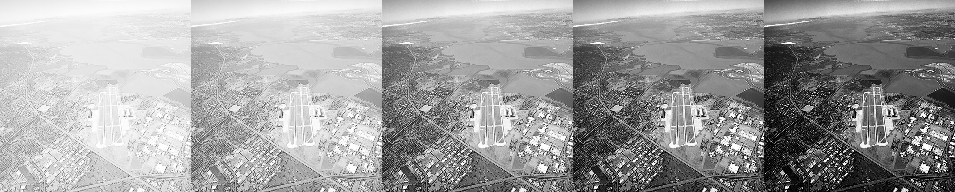

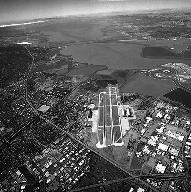

In [143]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0309(a)(washed_out_aerial_image).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0309(a)(washed_out_aerial_image).tif')
img = cv.resize(img, dsize=(0, 0), fx=0.25, fy=0.25)

#해당 실험 결과는 감마가 높을수록 어두워지는 전형적인 감마함수다. 따라서 L-1인 255 * f1^gamma를 한다.
# f(x) = (L-1) * x^gamma
def gamma(f, gamma=1.0):
  f1=f/255.0
  return np.uint8(255*(f1**gamma))

#어둡게 하는 다른 방식으로는 로그를 반전시켜서 쓸 수 있다.
#기존 로그함수 f(x) = ((L - 1)/logL) * log(1+x)
#역함수 f(x) = exp^(x * (logL / (L - 1))) - 1
def logfunc(f):
  return np.uint8(np.exp(f*(np.log(256) / 255)) - 1)


gc = np.hstack((gamma(img,0.5),gamma(img,1),gamma(img,2),gamma(img,3),gamma(img,5)))
gclog = logfunc(img)

cvshow(gc)
cvshow(gclog)

cv.waitKey()
cv.destroyAllWindows()
#결과적으로 역로그 함수는 감마 멱함수에서 감마를 5로 설정한 값과 유사한 결과를 출력하는 것을 볼 수 있다.

In [140]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0310(b)(washed_out_pollen_image).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0310(b)(washed_out_pollen_image).tif')

img = cv.resize(img, dsize=(0, 0), fx=0.25, fy=0.25)

#(0, 0)과 (s1, r1)의 기울기 방정식 = r1 / s1
#(s1, r1)과 (s2, r2)의 기울기 방정식 = (r2 - r1) / (s2 - s1)
#(s2, r2)와 (255, 255)의 기울기 방정식 = (255 - r2) / (255 - s2)
#선과 점의 방정식 (y - r1) = m(x - s1)
def two_pointed_linear(f, s1, r1, s2, r2):
  f1 = f/255.0
  result = f1.copy()
  if s1 != 0:
    slope = r1 / s1
    result[f1 < s1] = slope * f1[f1 < s1]
  if s2 - s1 != 0:
    slope2 = (r2 - r1) / (s2 - s1)
    result[(f1 >= s1) & (f1 < s2)] = slope2 * (f1[(f1 >= s1) & (f1 < s2)] - s1) + r1
  if 1.0 - s2 != 0:
    slope3 = (1.0 - r2) / (1.0 - s2)
    result[f1 >= s2] = slope3 * (f1[f1 >= s2] - s2) + r2
  return np.uint8(result * 255)

gc = np.hstack((two_pointed_linear(img, 0.4, 0.1, 0.6, 0.9),  two_pointed_linear(img, 0.42, 0.1, 0.47, 0.9)))
gc2 = np.hstack((two_pointed_linear(img, 0.4, 0.1, 0.45, 0.9),  two_pointed_linear(img, 0.4, 0.1, 0.44, 0.9)))
gc3 = np.hstack((two_pointed_linear(img, 0.45, 0.1, 0.51, 0.9),  two_pointed_linear(img, 0.53, 0.1, 0.54, 0.9)))
cvshow(gc)
cvshow(gc2)
cvshow(gc3)
cvshow(two_pointed_linear(img, 0.4, 0.1, 0.53, 0.9))

cv.waitKey()
cv.destroyAllWindows()
#분석결과 해당 그림의 대부분은 1로 정규화 시 0.4에서 0.53정도의 밝기에 대다수의 정보가 분포하는 것으로 파악된다

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


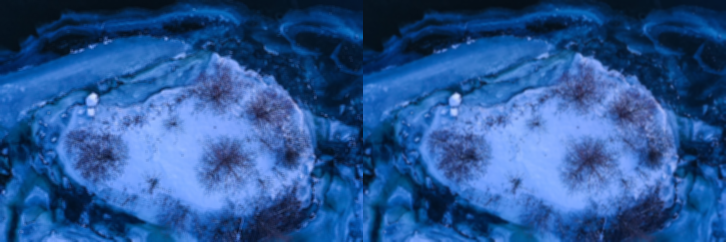

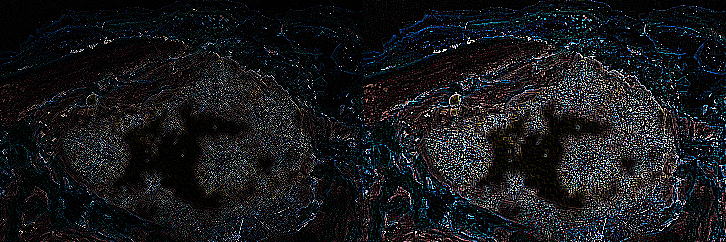

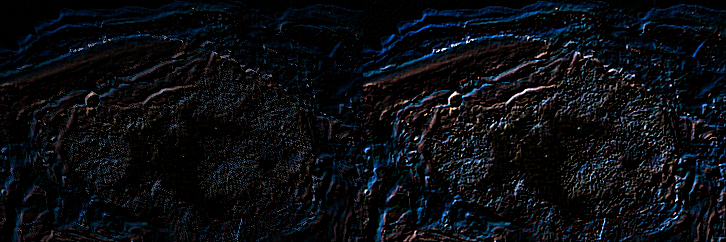

In [ ]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/230632.png')

#기타 파일용
img = cv.imread('./Datas/Assign1/230632.png')

img = cv.resize(img, dsize=(0, 0), fx=0.25, fy=0.25)

filt1 = np.array([[1/9.0,1/9.0,1/9.0],[1/9.0,1/9.0,1/9.0],[1/9.0,1/9.0,1/9.0]])
filt2 = np.array([
[0.003, 0.0133, 0.0219, 0.0133, 0.003],
[0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
[0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
[0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
[0.003, 0.0133, 0.0219, 0.0133, 0.003]])
filt3 = np.array([[0, -1, 0],[-1, 4, -1],[0, -1, 0]])
filt4 = np.array([[-1, -1, -1],[-1, 8, -1],[-1, -1, -1]])
filt5 = np.array([[-1, 0, 0], [0, 0, 0], [0, 0, 1]])
filt6 = np.array([[-1, -1, 0], [-1, 0, 1], [0, 1, 1]])

img1 = cv.filter2D(img, -1, filt1)
img2 = cv.filter2D(img, -1, filt2)
img3 = cv.filter2D(img, -1, filt3)
img4 = cv.filter2D(img, -1, filt4)
img5 = cv.filter2D(img, -1, filt5)
img6= cv.filter2D(img, -1, filt6)

gc = np.hstack((img1, img2))
gc2 = np.hstack((img3, img4))
gc3 = np.hstack((img5, img6))

cvshow(gc)
cvshow(gc2)
cvshow(gc3)

cv.waitKey()
cv.destroyAllWindows()
#1 : 박스 컨볼루션 2 : 가우시안 컨볼루션
#1-2의 경우 가우시안 컨볼루션이 5x5크기의 박스에 고르게 분포하게 설정되어 있어서 더 흐리게 보이는 것을 알 수 있다.
#하지만 3x3과 5x5로 중앙을 기준으로 1픽셀 차이, 검출이 아닌 블러링 처리이기 때문에 차이가 작아 육안으로 구분하는 것은 매우 어렵다

#3-4는 2차 미분 컨볼루션으로 4방향으로 뻗은 3과 달리 8방향으로 뻗은 4로 인해 4가 더욱 변화에 민감하게 반응하는 것을 볼 수 있다.
#다만, 그만큼 노이즈에도 민감해진다.

#5-6은 대각선 45도 방향에 대한 1차 미분 컨볼루션으로 5는 대각선과 인접하는 엣지는 검출하지 않고, 6은 검출한다.
#그로 인해서 대각선으로 포함하는 범주가 6이 비교적 선명한 것을 볼 수 있다. 대신, 6의 경우 확실하게 대각선이 아닌 부분도 더 강하게 검출된다.

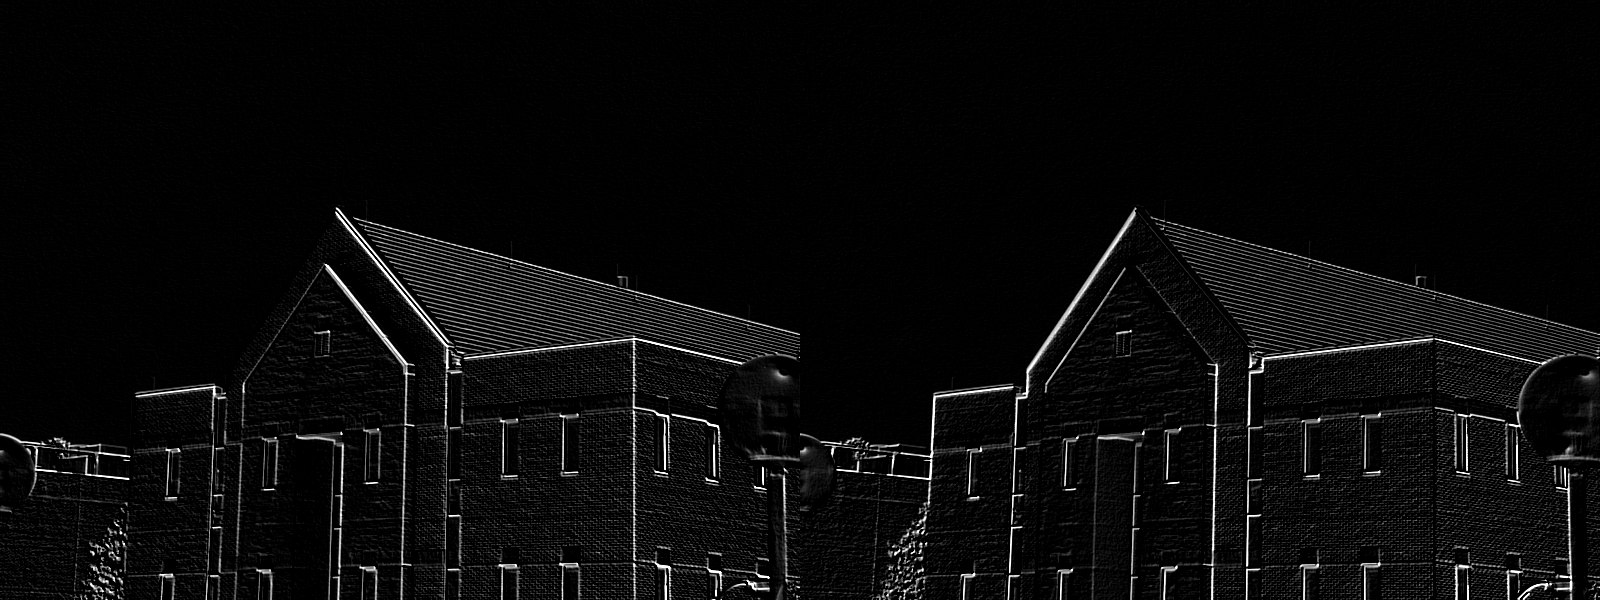

In [ ]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/school.jpg')

#기타 파일용
img = cv.imread('./Datas/Assign1/school.jpg')

img = cv.resize(img, dsize=(0, 0), fx=0.5, fy=0.5)

#sobel연산자를 45도 회전
filt1 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]])
#-45도 회전
filt2 = np.array([
    [ 2,  1,  0],
    [1,  0,  -1],
    [0, -1,  -2]])

img1 = cv.filter2D(img, -1, filt1)
img2 = cv.filter2D(img, -1, filt2)

gc = np.hstack((img1, img2))

cvshow(gc)

cv.waitKey()
cv.destroyAllWindows()

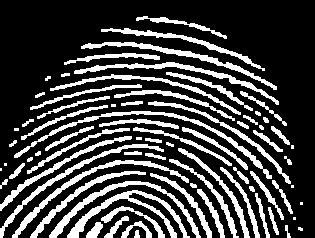

In [134]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/finger.jpg')

#기타 파일용
img = cv.imread('./Datas/Assign1/finger.jpg')

img = cv.resize(img, dsize=(0, 0), fx=1, fy=1)

#먼저 open연산을 통해 노이즈를 제거한다
filt1 = np.full((3,3), 1)
img1 = cv.erode(img, filt1, iterations=1)
img1 = cv.dilate(img1, filt1, iterations=1)

#후에 close연산을 통해 지문의 매우 얇은 틈을 메워 안정적으로 지문내부의 구멍을 잇는다
filt2 = np.full((3,3), 1)
img1 = cv.dilate(img1, filt2, iterations=1)
img1 = cv.erode(img1, filt2, iterations=1)

cvshow(img1)

cv.waitKey()
cv.destroyAllWindows()

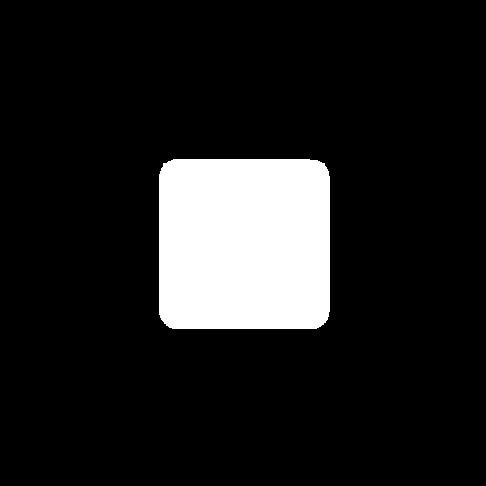

In [141]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0905(a)(wirebond-mask).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0905(a)(wirebond-mask).tif')

img = cv.resize(img, dsize=(0, 0), fx=1, fy=1)

#필터 사이즈를 두꺼운 선의 형태소보다 크게 해서 open연산을 사용해 사각형만 남겼다.
#만일 두꺼운 선분을 남기고 싶으면 필터의 크기를 점진적으로 작게 하면 된다.
filt1 = np.full((60,60), 1)
img1 = cv.erode(img, filt1, iterations=1)
img1 = cv.dilate(img1, filt1, iterations=1)

cvshow(img1)

cv.waitKey()
cv.destroyAllWindows()

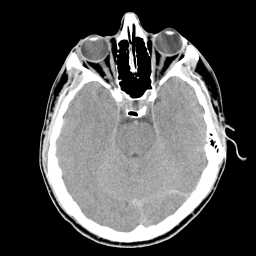

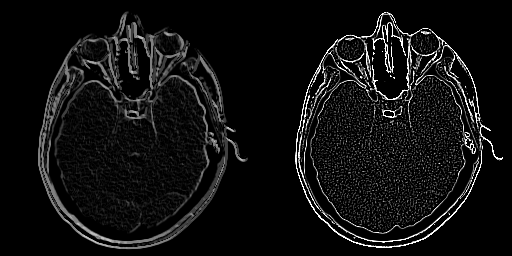

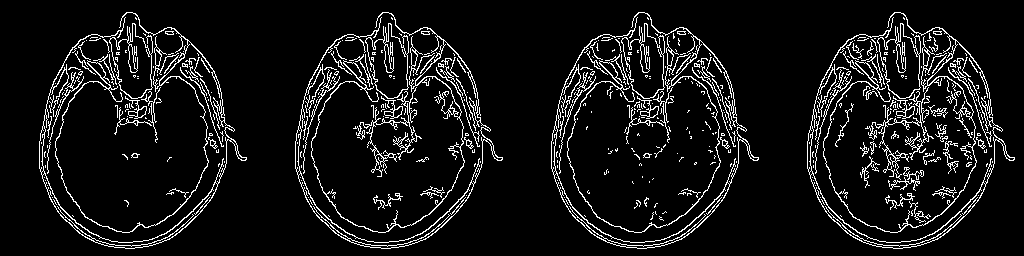

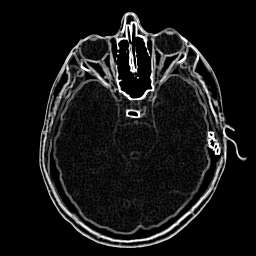

In [ ]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0939(a)(headCT-Vandy).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0939(a)(headCT-Vandy).tif')

img = cv.resize(img, dsize=(0, 0), fx=0.5, fy=0.5)

#Sobel
filt1 = np.array([
    [ -1,  0,  1],
    [-2,  0,  2],
    [-1, 0,  1]])
filt2 = np.array([
    [ -1,  -2,  -1],
    [0,  0,  0],
    [-1, -2,  -1]])
filt3 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]])
filt4 = np.array([
    [ 2,  1,  0],
    [1,  0,  -1],
    [0, -1,  -2]])

sobimg1 = cv.filter2D(img, -1, filt1)
sobimg2 = cv.filter2D(img, -1, filt2)
sobimg3 = cv.filter2D(img, -1, filt3)
sobimg4 = cv.filter2D(img, -1, filt4)

sobimg = cv.addWeighted(sobimg1, 0.5, sobimg2, 0.5, 0)
sobimg = cv.addWeighted(sobimg, 0.6666, sobimg3, 0.3333, 0)
sobimg = cv.addWeighted(sobimg, 0.75, sobimg4, 0.25, 0)

#Laplacian(잡음 민감)
lapfilt = np.array([[-1, -1, -1],[-1, 8, -1],[-1, -1, -1]])

lapimg = cv.filter2D(img, -1, lapfilt)


#Canny
cannyimg = cv.Canny(img, 100, 200)
cannyimg2 = cv.Canny(img, 50, 200)
cannyimg3 = cv.Canny(img, 100, 150)
cannyimg4 = cv.Canny(img, 50, 150)

#Morphological Gradient
MPfilt = np.full((5,5), 1)
erodeimg = cv.erode(img, MPfilt, iterations=1)

resimg = cv.subtract(img, erodeimg)


gc = np.hstack((sobimg, lapimg))
gc2 = np.hstack((cannyimg, cannyimg2,cannyimg3, cannyimg4))

cvshow(img)
cvshow(gc)
cvshow(gc2)
cvshow(resimg)

cv.waitKey()
cv.destroyAllWindows()

#소벨은 1차 미분을 이용하기 때문에 점진적 변화를 잘 감지하지 못한다. 다만, 해당 사진에서 점진적 변화가 일어나는 부분이 거의 없으므로 해당 예제에서는 잘 보이지 않는다.
#라플라시안은 2차 미분을 이용하기 때문에 잡음에 의해 크게 튀는 경향성이 있다.
#캐니는 임계점 설정에 따라 성능이 극단적으로 나뉜다. 임계점이 높은 첫 사진은 감지해야할 뇌 안장등이 소실된 것을 볼 수 있고, 마지막 사진은 뇌척수액을 예민하게 감지해서 구조가 잘 보이지 않는다.
#모폴로지 그래디언트는 위 방식에 비해 변화량보다 형태를 기준으로 선별하기 때문에 기존의 명암이 보존되는 특징을 볼 수 있다.

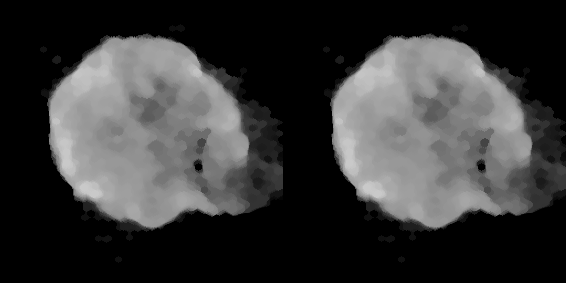

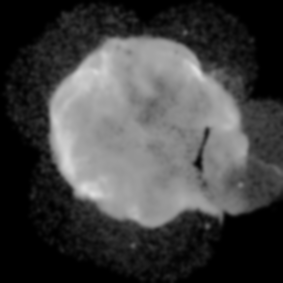

In [102]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0938(a)(cygnusloop_Xray_original).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0938(a)(cygnusloop_Xray_original).tif')

img = cv.resize(img, dsize=(0, 0), fx=0.5, fy=0.5)

filt1 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7,7))
#열림
img1 = cv.erode(img, filt1, iterations=1)
img1 = cv.dilate(img1, filt1, iterations=1)
#후 닫힘
img1 = cv.dilate(img1, filt1, iterations=1)
img1 = cv.erode(img1, filt1, iterations=1)

#닫힘
img2 = cv.erode(img, filt1, iterations=1)
img2 = cv.dilate(img2, filt1, iterations=1)
#후 열림
img2 = cv.dilate(img2, filt1, iterations=1)
img2 = cv.erode(img2, filt1, iterations=1)

img3 = cv.GaussianBlur(img, (9,9), 0)

gc = np.hstack((img1, img2))

cvshow(gc)
cvshow(img3)

cv.waitKey()
cv.destroyAllWindows()
#모폴로지를 이용한 노이즈 제거는 필터를 작업단위로 이용하기 때문에 노이즈 제거에는 탁월하나 이미지의 필터 크기가 과하게 클 경우 이미지의 디테일이 뭉개지는 문제가 있다.
#가우시안을 이용한 노이즈 제거는 실질적으로 정규분포에 따라 분산한 것에 불과하므로 원형이 상대적으로 덜 뭉개지나 노이즈 제거가 아닌 분산에 가깝다.

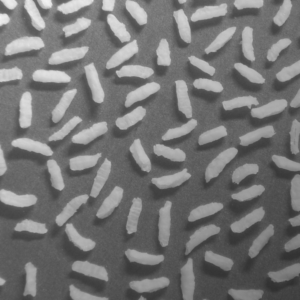

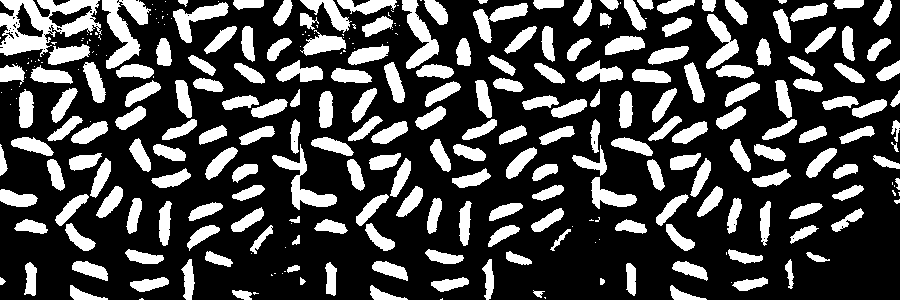

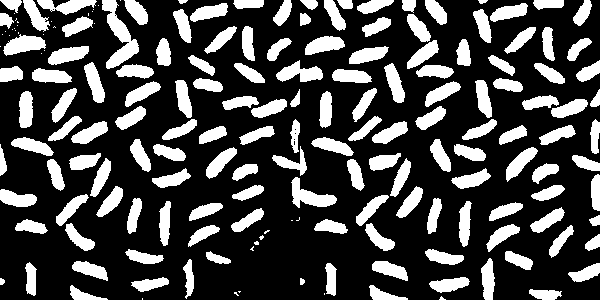

In [40]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0940(a)(rice_image_with_intensity_gradient).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0940(a)(rice_image_with_intensity_gradient).tif')

img = cv.resize(img, dsize=(0, 0), fx=0.5, fy=0.5)

#임의 결정 임계점 방식
def thres(f, k):
  f1 = f/255.0
  res = f1.copy()
  res[f1 < k] = 0
  res[f1 >= k] = 1.0
  return np.uint8(res * 255)

gc = np.hstack((thres(img, 0.5),thres(img, 0.52),thres(img, 0.55)))

#순수 otsu
otsu_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
ret, otsu_img = cv.threshold(otsu_img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

#Top-hat W후 otsu
MPfilt = np.full((25,25), 1)
erodeimg = cv.erode(img, MPfilt, iterations=1)
erodeimg = cv.dilate(erodeimg, MPfilt, iterations=1)
resimg = cv.subtract(img, erodeimg)
otsu_img2 = cv.cvtColor(resimg, cv.COLOR_BGR2GRAY)
ret, otsu_img2 = cv.threshold(otsu_img2, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

gc2 = np.hstack((otsu_img, otsu_img2))

cvshow(img)
cvshow(gc)
cvshow(gc2)

cv.waitKey()
cv.destroyAllWindows()
#두번째 줄 결과 : 사용자가 임의로 결정한 threshold
#문제는 왼쪽 위 배경이 조명으로 인해 왼쪽 아래쪽 쌀알보다 밝아서 임계점을 낮추면(1번) 오른쪽 위가 조명으로 인해 노이즈가 생기고 임계점을 높이면(2-3번) 왼쪽 아래가 소실된다.
#세번째 줄의 첫번째 결과도 크게 다를게 없는 것이, otsu는 히스토그램을 통해 적절한 임계점을 찾는 것일 뿐 조명을 보정해 주는 것이 아니기 때문에 두번째 줄에서 나타난 두가지 문제 중 하나가 반드시 발생한다.
#따라서 white top-hat을 통해 쌀알을 제외한 배경을 지우고 쌀알만 남긴 후 otsu를 적용해서 세번째 줄 2번째 사진으로 성공한 모습이다.

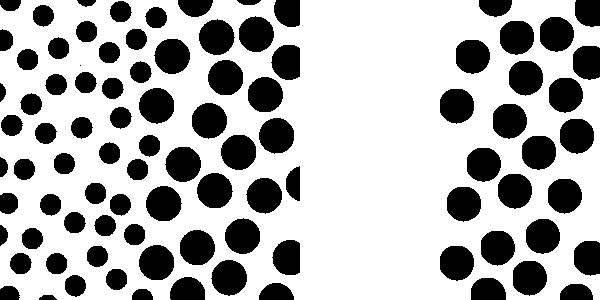

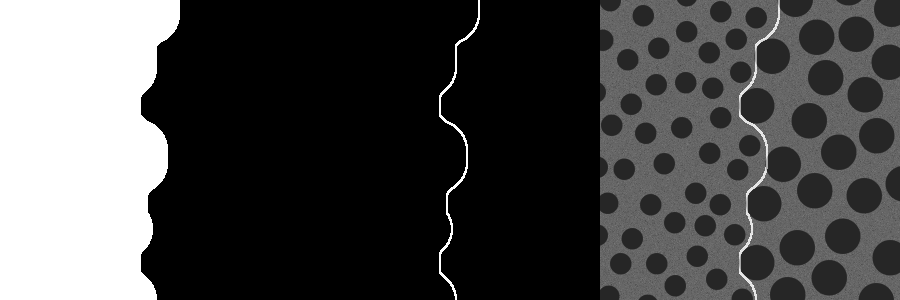

In [138]:
#구글 드라이브일 경우 아래 코드 사용
#img = cv.imread('/content/drive/MyDrive/ComputerVision/Datas/Assign1/Fig0943(a)(dark_blobs_on_light_background).tif')

#기타 파일용
img = cv.imread('./Datas/Assign1/Fig0943(a)(dark_blobs_on_light_background).tif')

img = cv.resize(img, dsize=(0, 0), fx=0.5, fy=0.5)
#채널 통일
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#otsu
ret, otsu_img = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

#클로즈 연산
MPfilt = cv.getStructuringElement(cv.MORPH_ELLIPSE, (30,30)) #30x30크기의 원형 필터를 제작함
closedimg = otsu_img.copy()
closedimg = cv.dilate(closedimg, MPfilt, iterations=1)
closedimg = cv.erode(closedimg, MPfilt, iterations=1)

#오픈 연산
MPfilt = cv.getStructuringElement(cv.MORPH_ELLIPSE, (60,60))
openedimg = closedimg.copy()
openedimg = cv.erode(openedimg, MPfilt, iterations=1)
openedimg = cv.dilate(openedimg, MPfilt, iterations=1)

#엣지 연산
MPfilt = np.full((5,5), 1)
edgedimg = cv.subtract(openedimg, cv.erode(openedimg, MPfilt, iterations=1))

#결과
res = cv.addWeighted(img, 0.5, edgedimg, 0.5, 0)

gc = np.hstack((otsu_img, closedimg))
gc2 = np.hstack((openedimg, edgedimg, res))

cvshow(gc)
cvshow(gc2)

cv.waitKey()
cv.destroyAllWindows()
#본래 사각형 필터를 썼으나 사각형의 경우 close연산으로 남는 큰 hole이 뭉툭해지는 문제가 있어서 원형 필터로 바꿨다.
#순서 : otsu로 배경과 이미지의 구분을 이진+선명화 -> close연산으로 작은 원을 지움 -> open연산으로 큰 원의 사이를 열음 -> 원본 - 침식 모폴로지를 통해 윤곽선만 남김 -> 윤곽선을 원본에 대입